# Integration with Python - Part A - Introduction

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In this notebook we will learn how to perform "numerical integration" to computationally compute approximations for integrals.

FYI: The term "numerical quadrature" or just "quadrature" is often used as a synonym for numerical integration. In fact, we will find in the next notebook that the SciPy tool for numerical integration is called quad().

### Setup

We will practice first by defining an integral we can solve easily by hand. We will then compare the numerical integration results to the true value. Later we will use these numerical techniques to solve integrals which can not be solved analytically.

Lets use the same function defined in the book:

Define $f(x) = x^4-2x +1$

Note $\int_0^2 (x^4-2x +1) dx = (\frac{x^5}{5} - x^2 + x) \big|_0^2 = 32/5 - 4 + 2 = 4.4 $

In [2]:
 def f(x):
    return x**4 - 2*x +1

In [3]:
integral_true = 4.4

## Left Riemann Sum - Integrating with left justified rectangular slices

In [4]:
# Define parameters for numerical integration
N = 10  # Number of slices
a = 0.0 # Lower bound
b = 2.0 # Upper bound
w = (b-a)/N # Step size
print("Step size ",w)

Step size  0.2


[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2. ]


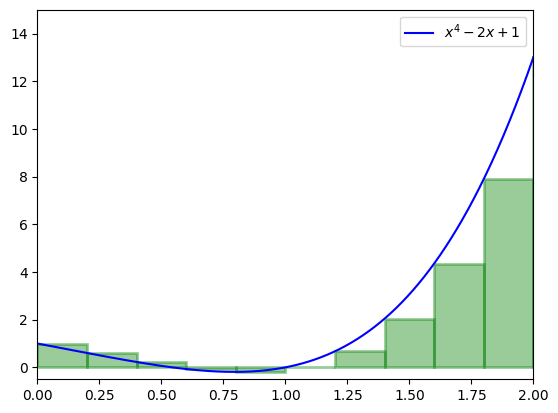

In [5]:
# Visualize numerical integration using rectangles - left Reimann Sum
ax = plt.axes(xlim=(a, b), ylim = (-0.5, 15))

# Plot the function
x = np.linspace(a, b, 1000) # Use many points so it is smooth
y = f(x)
ax.plot(x, y, c='blue', label='$x^4 -2x+1$')
ax.legend()

# Plot the rectangles
x = np.linspace(a, b, N + 1)
print(x)
y = f(x)
bar = ax.bar(x, y, width=w, alpha=0.4, align='edge', color='green', edgecolor='green', lw=2)

In [6]:
# Integrating a function
#   with rectangular slices (Left Riemann sum)

N = 10  # Number of slices
a = 0.0 # Lower bound
b = 2.0 # Upper bound
w = (b-a)/N # Step size
print("Step size ",w)

# Create an array entry for each step
x = np.linspace(a, b, N, endpoint = False)
print("Step locations",x)

# Calculate numerical integral
s=0
for k in x:
    s+= f(k)*w
print("Integral =",s)

Step size  0.2
Step locations [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8]
Integral = 3.306560000000001


In [7]:
# Define the same integral estimator as a function
def rectangular_integral_left(N,a,b):
    # Step size
    w = (b-a)/N

    # Create an array entry for each step
    x = np.linspace(a, b, N, endpoint = False)

    # Calculate numerical integral
    s=0
    for k in x:
        s+= f(k)*w
    return s

In [21]:
print(f"Left Sum (N=10):     {rectangular_integral_left(10,a,b)}")
print(f"Left Sum (N=100):    {rectangular_integral_left(100,a,b)}")
print(f"Left Sum (N=1000):   {rectangular_integral_left(1000,a,b)}")

Left Sum (N=10):     3.306560000000001
Left Sum (N=100):    4.281066655999999
Left Sum (N=1000):   4.3880106666656


In [12]:
# Note: we can do the same thing without a loop using numpy vectorization (this is faster)
def rectangular_integral_left_vec(N,a,b):
    w = (b-a)/N
    # Create an array of N left-edge coordinates
    x = np.linspace(a, b, N, endpoint=False)
    # Calculate all y-values at once
    y = f(x)
    # Sum all y-values and multiply by the width
    return np.sum(y) * w

In [13]:
print(f"Vectorized Left Sum (N=10):   {rectangular_integral_left_vec(10,a,b)}")
print(f"Vectorized Left Sum (N=10):   {rectangular_integral_left_vec(100,a,b)}")
print(f"Vectorized Left Sum (N=1000): {rectangular_integral_left_vec(1000,a,b)}")

Vectorized Left Sum (N=10):   3.3065600000000006
Vectorized Left Sum (N=10):   4.281066656
Vectorized Left Sum (N=1000): 4.388010666665601


With  1000  iterations we found I =  4.3880106666656


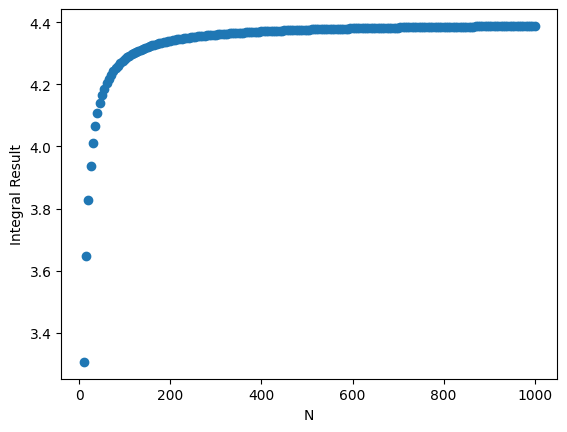

In [ ]:
# Check how the integral result changes with increasing N
N_array = np.arange(10,1005,5,dtype='int64')
integral_results_rect_left = []
for N in N_array:
    integral_results_rect_left.append(rectangular_integral_left(N,a,b))

plt.plot(N_array,integral_results_rect_left,"o")
plt.xlabel("N")
plt.ylabel("Integral Result")

print("With ",N_array[-1]," iterations we found I = ",integral_results_rect_left[-1])

## Midpoint Riemann Sum - Integrating with center justified rectangular slices

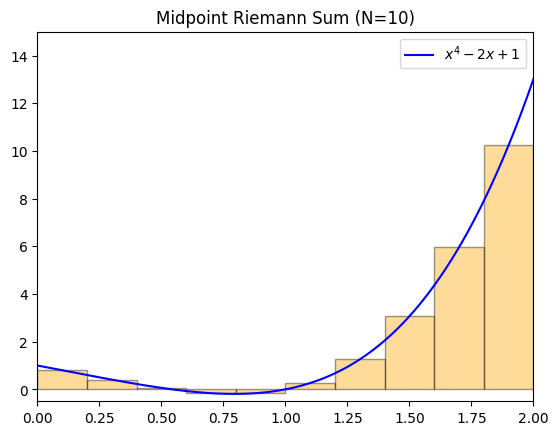

In [ ]:
# Visualize numerical integration using rectangles - midpoint Reimann Sum
N = 10
a = 0.0
b = 2.0
w = (b-a)/N

# Plot the smooth function
x_smooth = np.linspace(a, b, 1000)
y_smooth = f(x_smooth)
ax = plt.axes(xlim=(a, b), ylim = (-0.5, 15))
ax.plot(x_smooth, y_smooth, c='blue', label='$x^4 -2x+1$')

# Create x-coordinates for the midpoints
# We want N points, from the first midpoint (a + w/2) to the last (b - w/2)
x_mid = np.linspace(a + w/2, b - w/2, N, endpoint=True)
y_mid = f(x_mid)

# Plot the rectangles
ax.bar(x_mid, y_mid, width=w, alpha=0.4, align='center', color='orange', edgecolor='black', lw=1)
ax.legend()
plt.title(f"Midpoint Riemann Sum (N={N})")
plt.show()

In [ ]:
# Integrating a function
#   with rectangular slices (Midpoint Riemann sum)

N = 10  # Number of slices
a = 0.0 # Lower bound
b = 2.0 # Upper bound
w = (b-a)/N # Step size
print("Step size ",w)

# Create an array entry for each step
x = np.linspace(a+w/2, b+w/2, N, endpoint = False)
print("Step locations",x)

# Calculate numerical integral
s=0
for k in x:
    s+= f(k)*w
print("Integral =",s)

Step size  0.2
Step locations [0.1 0.3 0.5 0.7 0.9 1.1 1.3 1.5 1.7 1.9]
Integral = 4.346760000000002


In [15]:
# Now lets do the same but with a function
def rectangular_integral_midpoint(N,a,b):

    # Step size
    w = (b-a)/N

    # Create an array entry for each step
    x = np.linspace(a+w/2, b+w/2, N, endpoint = False)

    # Calculate numerical integral
    s=0
    for k in x:
        s+= f(k)*w
    return s

In [20]:
print(f"Midpoint Sum (N=10):     {rectangular_integral_midpoint(10,a,b)}")
print(f"Midpoint Sum (N=100):    {rectangular_integral_midpoint(100,a,b)}")
print(f"Midpoint Sum (N=1000):   {rectangular_integral_midpoint(1000,a,b)}")

Midpoint Sum (N=10):     4.346760000000002
Midpoint Sum (N=100):    4.399466675999998
Midpoint Sum (N=1000):   4.399994666667596


In [18]:
# Note we can do the same thing without a loop:
def rectangular_integral_midpoint_vec(N,a,b):
    w = (b-a)/N
    # Create an array of N midpoint coordinates
    x = np.linspace(a + w/2, b - w/2, N, endpoint=True)
    y = f(x)
    return np.sum(y) * w


In [19]:

print(f"Vectorized Mid Sum (N=10):   {rectangular_integral_midpoint_vec(10,a,b)}")
print(f"Vectorized Mid Sum (N=10):   {rectangular_integral_midpoint_vec(100,a,b)}")
print(f"Vectorized Mid Sum (N=1000): {rectangular_integral_midpoint_vec(1000,a,b)}")

Vectorized Mid Sum (N=10):   4.346759999999999
Vectorized Mid Sum (N=10):   4.399466676000001
Vectorized Mid Sum (N=1000): 4.399994666667599


With  1000  iterations we found I =  4.399994666667596


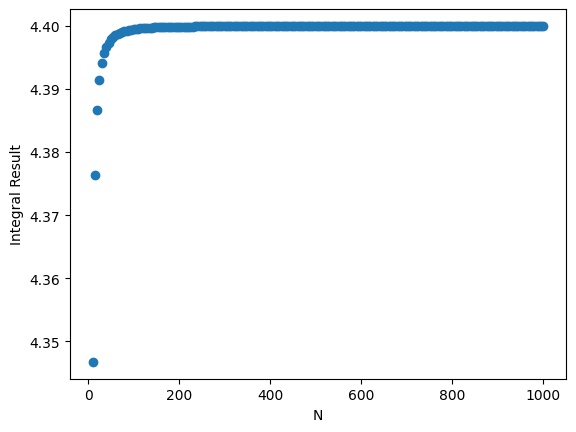

In [ ]:
# Check how the integral result changes with increasing N
N_array = np.arange(10,1005,5,dtype='int64')
integral_results_rect_mid = []
for N in N_array:
    integral_results_rect_mid.append(rectangular_integral_midpoint(N,a,b))

plt.plot(N_array,integral_results_rect_mid,"o")
plt.xlabel("N")
plt.ylabel("Integral Result")

print("With ",N_array[-1]," iterations we found I = ",integral_results_rect_mid[-1])

## Right Riemann Sum - Integrating with right justified rectangular slices

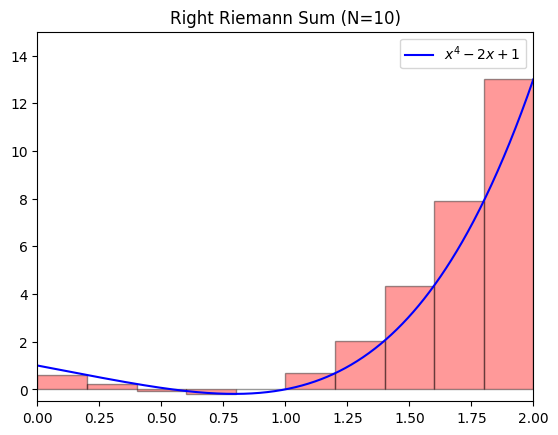

In [ ]:
# Visualize numerical integration using rectangles - right Reimann Sum
N = 10
a = 0.0
b = 2.0
w = (b-a)/N

# Plot the smooth function
x_smooth = np.linspace(a, b, 1000)
y_smooth = f(x_smooth)
ax = plt.axes(xlim=(a, b), ylim = (-0.5, 15))
ax.plot(x_smooth, y_smooth, c='blue', label='$x^4 -2x+1$')

# Create x-coordinates for the right edges
# We want N points, from the first right edge (a + w) to the last (b)
x_right = np.linspace(a + w, b, N, endpoint=True)
y_right = f(x_right)

# Plot the rectangles
# Use align='edge' (left-aligned) but with a negative width
ax.bar(x_right, y_right, width=-w, alpha=0.4, align='edge', color='red', edgecolor='black', lw=1)
ax.legend()
plt.title(f"Right Riemann Sum (N={N})")
plt.show()

In [22]:
# Right Reimann sum function
def rectangular_integral_right(N,a,b):

    # Step size
    w = (b-a)/N

    # Create an array entry for each step
    x = np.linspace(a+w, b+w, N, endpoint = False)

    # Calculate numerical integral
    s=0
    for k in x:
        s+= f(k)*w
    return s

In [26]:
print(f"Right Sum (N=10):       {rectangular_integral_right(10,a,b)}")
print(f"Right Sum (N=100):      {rectangular_integral_right(100,a,b)}")
print(f"Right Sum (N=1000):     {rectangular_integral_right(1000,a,b)}")

Right Sum (N=10):       5.706560000000001
Right Sum (N=100):      4.5210666559999995
Right Sum (N=1000):     4.412010666665594


In [29]:
# Do the same thing with no for loop
def rectangular_integral_right_vec(N,a,b):
    w = (b-a)/N
    # Create an array of N right-edge coordinates
    x = np.linspace(a + w, b, N, endpoint=True)
    y = f(x)
    return np.sum(y) * w

In [28]:
print(f"Vectorized Right Sum (N=10):    {rectangular_integral_right_vec(10,a,b)}")
print(f"Vectorized Right Sum (N=100):   {rectangular_integral_right_vec(100,a,b)}")
print(f"Vectorized Right Sum (N=1000):  {rectangular_integral_right_vec(1000,a,b)}")

Vectorized Right Sum (N=10):    5.7065600000000005
Vectorized Right Sum (N=100):   4.521066656
Vectorized Right Sum (N=1000):  4.4120106666656005


With  1000  iterations we found I =  4.412010666665594


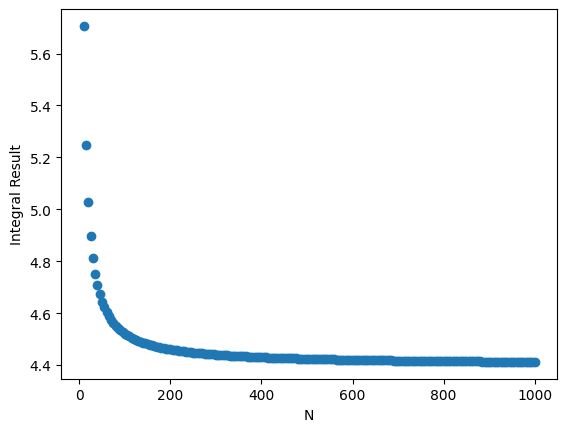

In [30]:
# Check how the integral result changes with increasing N
N_array = np.arange(10,1005,5,dtype='int64')
integral_results_rect_right = []
for N in N_array:
    integral_results_rect_right.append(rectangular_integral_right(N,a,b))

plt.plot(N_array,integral_results_rect_right,"o")
plt.xlabel("N")
plt.ylabel("Integral Result")

print("With ",N_array[-1]," iterations we found I = ",integral_results_rect_right[-1])

## Comparing Integration Methods

Text(0, 0.5, 'Integral Result')

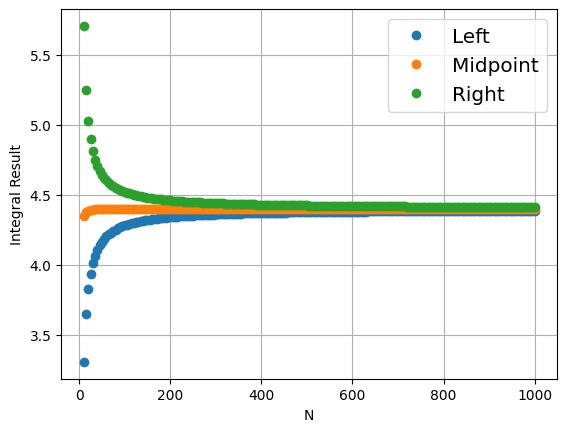

In [ ]:
plt.plot(N_array,integral_results_rect_left,"o",label="Left")
plt.plot(N_array,integral_results_rect_mid,"o",label="Midpoint")
plt.plot(N_array,integral_results_rect_right,"o",label="Right")
plt.grid(True)
plt.legend(loc='upper right', fontsize='x-large')
plt.xlabel("N")
plt.ylabel("Integral Result")

(4.3, 4.5)

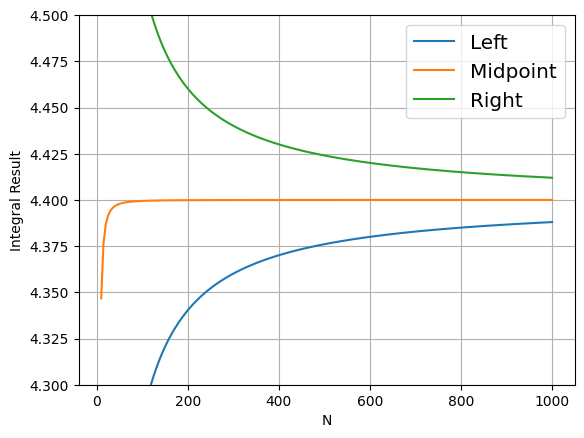

In [ ]:
plt.plot(N_array,integral_results_rect_left,"-",label="Left")
plt.plot(N_array,integral_results_rect_mid,"-",label="Midpoint")
plt.plot(N_array,integral_results_rect_right,"-",label="Right")
plt.grid(True)
plt.legend(loc='upper right', fontsize='x-large')
plt.xlabel("N")
plt.ylabel("Integral Result")
plt.ylim(4.3,4.5)

We can see that the Left and Right Sums converge relatively slowly, while the Midpoint Sum converges much more quickly. Even at a low $N$, its value is significantly closer to the true value 4.4 than the other two.

For this function which is increasing on the interval from 0-2, the Left Sum consistently underestimates the true value (in the plot above the rectangles are mostly under the curve). The Right Sum consistently overestimates the true value for this function on this interval. The Midpoint Riemann Sum has a much smaller error. The errors from the parts of the rectangle that are over the curve and under the curve tend to cancel each other out, leading to a much better approximation.

The speed of convergence can be formally described by looking at how the total error scales with the number of slices, $N$. We will discuss this more later, but for now:

* **Left & Right Riemann Sums:** The error for these methods is proportional to $1/N$. This is also written as $O(1/N)$. If you double the number of slices, you cut the error in half.
* **Midpoint** The error for is proportional to $1/N^2$. This is also written as $O(1/N^2)$. If you double the number of slices, you cut the error by a factor of four ($2^2$).

If you use $N=100$ slices:
* The Left/Right error scales like $1/100$ (0.01).
* The Midpoint error scales like $1/100^2$ (0.0001).

The error for the Midpoint rule shrinks *quadratically*, which is dramatically faster than the *linear* shrinkage of the Left and Right sums.

## Extended Trapezoid Rule

The Extended Trapezoid Rule breaks the total integral (from $a$ to $b$) into $N$ small slices, each with a width $w = (b-a)/N$. It then calculates the area of each slice using the trapezoid area formula [1/2*w*(height of left side)(height of right side)] and sums their areas together.

In writing I will demonstrate how we create a more computationally efficient version of this, where the two endpoints ($f(a)$ and $f(b)$) are weighted by 0.5, but all other interior points are weighted by 1.0:

$I_{\text{extended}} \approx w \times \left[ \frac{1}{2}f(a) + \frac{1}{2}f(b) + \sum_{k=1}^{N-1} f(a+kw) \right]$

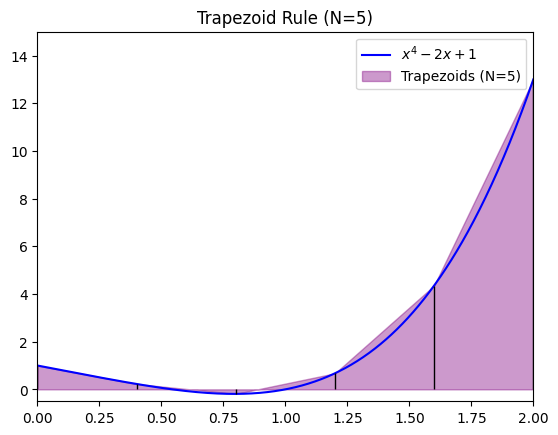

In [43]:
# Let's try to visualize the Trapezoid Rule :
N = 5
a = 0.0
b = 2.0
w = (b-a)/N

# Plot the smooth function
x_smooth = np.linspace(a, b, 1000)
y_smooth = f(x_smooth)
ax = plt.axes(xlim=(a, b), ylim = (-0.5, 15))
ax.plot(x_smooth, y_smooth, c='blue', label='$x^4 -2x+1$')

# Create N+1 x-coordinates for the edges of the N trapezoids
x_edges = np.linspace(a, b, N + 1, endpoint=True)
y_edges = f(x_edges)

# Plot the trapezoids using fill_between
ax.fill_between(x_edges, y_edges, 0, alpha=0.4, color='purple', label=f'Trapezoids (N={N})')

# Add black vertical lines for the trapezoid edges
ax.vlines(x_edges, 0, y_edges, color='black', lw=1)

ax.legend()
plt.title(f"Trapezoid Rule (N={N})")
plt.show()

In [41]:
# Integrating a function
#   with the Extended Trapezoid Rule

N = 10  # Number of slices
a = 0.0 # Lower bound
b = 2.0 # Upper bound
w = (b-a)/N # Step size
print("Step size ",w)


# Calculate numerical integral
#   using the trapezoid rule for each slice
print("Trapezoid rule for each slice")
x = np.arange(1, N+1)
t = 0
for k in x:
    lb = a + k*w - w
    ub = a + k*w
    slice_area = 0.5*w*(f(lb)+f(ub))
    t+= slice_area
    print(f"   k {k}  LB {lb:.4f} UB {ub:.4f} Slice Area {slice_area:.4f}")

# Calculate numerical integral
#   using the extended trapezoid ruleprint("Trapezoid rule for each slice")
x = np.arange(1, N) # Note this is different (it is only to loop over the interior points)
# Start the sum 's' with the two endpoints (a and b), weighted by 0.5
s = 0.5*f(a) + 0.5*f(b)
# Add the function value for all interior points (weighted by 1.0)
for k in x:
    s+= f(a+k*w)
# Multiply the total weighted sum by the slice width 'w'
s = w*s

print(f"Trapezoid Result: {t:.8f}")
print(f"Extended Trapezoid Result: {s:.8f}")

Step size  0.2
Trapezoid rule for each slice
   k 1  LB 0.0000 UB 0.2000 Slice Area 0.1602
   k 2  LB 0.2000 UB 0.4000 Slice Area 0.0827
   k 3  LB 0.4000 UB 0.6000 Slice Area 0.0155
   k 4  LB 0.6000 UB 0.8000 Slice Area -0.0261
   k 5  LB 0.8000 UB 1.0000 Slice Area -0.0190
   k 6  LB 1.0000 UB 1.2000 Slice Area 0.0674
   k 7  LB 1.2000 UB 1.4000 Slice Area 0.2715
   k 8  LB 1.4000 UB 1.6000 Slice Area 0.6395
   k 9  LB 1.6000 UB 1.8000 Slice Area 1.2251
   k 10  LB 1.8000 UB 2.0000 Slice Area 2.0898
Trapezoid Result: 4.50656000
Extended Trapezoid Result: 4.50656000


## Exercise

<font color=magenta>----Begin Exercise 11-1----</font>

* Repeat the steps we did above for other algorithms
    * Define a function which calculates the integral of a function using the extended trapezoid rule. The inputs to the function should be N, a, and b.
    * Plot the value of the integral as a function of N (for all N from 10 to 1000 in steps of 5)
    * Make a plot comparing all 4 methods
* For the midpoint rule and trapzoid rule, calculate the percent error for each value of N (create a percent error array).

$\text{percent error} = 100\% \times\frac{(\text{Calculated value} - \text{true value})}{\text{true value}}$

* Make a plot comparing the percent error for the midpoint rule and trapezoid rule

<font color=magenta>----End Exercise----</font>

You should find the the trapezoid also converges fast. Both Midpoint and Trapezoid have error proportional to $1/N^2$.

For this particular function the Midpoint error is negative (it underestimates the true value) and the Trapezoid  error is positive (it overestimates the true value). This is only true because our function is concave up. The opposite will be true for a concave down function.

The Midpoint rule is approximately twice as accurate as the Trapezoid rule (its error curve is about half the magnitude of the trapezoid's).